# Code to determine the Correlations metric


In [117]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
# utilized in upset_frequency
def load_all_league_data():
    """
    Load match data and standings for all available leagues.
    
    Returns:
        tuple: (league_data_dict, standings_dict) where each is a dict of league_name -> DataFrame
    """
    base_dir = Path().resolve()
    
    # Define league configurations
    leagues = {
        'Premier League': {
            'matches_file': 'premier_league1_std.csv',
            'standings_file': 'premier_league_standings_all_seasons.csv'
        },
        'Serie A': {
            'matches_file': 'serie_a_std.csv',
            'standings_file': 'serie_a_standings_all_seasons.csv'
        },
        'Bundesliga': {
            'matches_file': 'bundesliga_std.csv',
            'standings_file': 'bundesliga_standings_all_seasons.csv'
        },
        'La Liga': {
            'matches_file': 'la_liga_std.csv',
            'standings_file': 'la_liga_standings_all_seasons.csv'
        }
    }
    
    league_data = {}
    standings_data = {}
    
    print("Loading league data...")   
    for league_name, config in leagues.items():
        # Load match data
        matches_path = base_dir / "../csv/processed" / config['matches_file']
        if matches_path.exists():
            matches_df = pd.read_csv(matches_path)
            matches_df['date'] = pd.to_datetime(matches_df['date'])
            league_data[league_name] = matches_df
            print(f"✓ Loaded {league_name} matches: {len(matches_df):,} matches")
        else:
            print(f"✗ Warning: {matches_path} not found")
            
        # Load standings data
        standings_path = base_dir / "../csv/auxiliary" / config['standings_file']
        if standings_path.exists():
            standings_df = pd.read_csv(standings_path)
            standings_data[league_name] = standings_df
            print(f"✓ Loaded {league_name} standings: {len(standings_df):,} team-seasons")
        else:
            print(f"✗ Warning: {standings_path} not found")
    
    print(f"\nSuccessfully loaded {len(league_data)} leagues")
    return league_data, standings_data
league_data, standings_data = load_all_league_data()
len(league_data["Premier League"]["season"].unique())

Loading league data...
✓ Loaded Premier League matches: 8,360 matches
✓ Loaded Premier League standings: 440 team-seasons
✓ Loaded Serie A matches: 8,518 matches
✓ Loaded Serie A standings: 454 team-seasons
✓ Loaded Bundesliga matches: 6,426 matches
✓ Loaded Bundesliga standings: 378 team-seasons
✓ Loaded La Liga matches: 8,740 matches
✓ Loaded La Liga standings: 460 team-seasons

Successfully loaded 4 leagues


22

In [122]:

results = []
def goal_calculation(team, games):
    home_goals = games.loc[games["home_team"] == team, "home_team_points"].sum() #sum up every home games goals
    away_goals = games.loc[games["away_team"] == team, "away_team_points"].sum() #sum up every away games goals
    return home_goals + away_goals


def correlation(team,season, matches_played):
    df = matches_played[matches_played["season"] == season]
    df = df[(df["home_team"] == team) | (df["away_team"] == team)]
    df = df.sort_values(by = "date", ascending= True)
    midpoint = len(df) // 2
    first_half = df.iloc[:midpoint]
    second_half = df.iloc[midpoint:]
    first_half_goals = goal_calculation(team, first_half)
    second_half_goals = goal_calculation(team, second_half)
    first_half_goals = (first_half_goals/len(first_half))/ 3 * 100
    second_half_goals = (second_half_goals/len(second_half)) / 3 * 100
    dictionary= {"team": team, "season": season, "first_half_goals": first_half_goals, "second_half_goals": second_half_goals}

    return dictionary


for league in league_data:
    df = league_data[league]
    unique_pairs = set(zip(df["season"], df["home_team"]))
    for season, team in unique_pairs:
        second=correlation(team, season, df)
        second["league"] = league
        results.append(second)
allleagues = pd.DataFrame(results)
allleagues=allleagues.sort_values(by = ["league", "season", "team"], ascending= True)

In [124]:
allleagues=allleagues.sort_values(by = ["league", "season", "team"], ascending= True)
allleagues.to_csv("correlation_metrics.csv", index=False)
allleagues


,team,season,first_half_goals,second_half_goals,league
928,BAY,2004,66.666667,84.313725,Bundesliga
1097,BIE,2004,47.058824,31.372549,Bundesliga
969,BOC,2004,27.450980,41.176471,Bundesliga
1156,DOR,2004,35.294118,72.549020,Bundesliga
1225,FRE,2004,21.568627,13.725490,Bundesliga
...,...,...,...,...,...
482,ROM,2024,40.350877,80.701754,Serie A
869,TOR,2024,36.842105,40.350877,Serie A
716,UDI,2024,43.859649,33.333333,Serie A
667,VEN,2024,24.561404,26.315789,Serie A


In [115]:
allleagues

,team,season,first_half_goals,second_half_goals,league
0,BAY,2004,34.0,43.0,Bundesliga
1,BIE,2004,24.0,16.0,Bundesliga
2,BOC,2004,14.0,21.0,Bundesliga
3,DOR,2004,18.0,37.0,Bundesliga
4,FRE,2004,11.0,7.0,Bundesliga
...,...,...,...,...,...
1727,ROM,2024,23.0,46.0,Serie A
1728,TOR,2024,21.0,23.0,Serie A
1729,UDI,2024,25.0,19.0,Serie A
1730,VEN,2024,14.0,15.0,Serie A


# Create Plots

     team  season  first_half_goals  second_half_goals      league
928   BAY    2004         66.666667          84.313725  Bundesliga
1097  BIE    2004         47.058824          31.372549  Bundesliga
969   BOC    2004         27.450980          41.176471  Bundesliga
1156  DOR    2004         35.294118          72.549020  Bundesliga
1225  FRE    2004         21.568627          13.725490  Bundesliga
...   ...     ...               ...                ...         ...
482   ROM    2024         40.350877          80.701754     Serie A
869   TOR    2024         36.842105          40.350877     Serie A
716   UDI    2024         43.859649          33.333333     Serie A
667   VEN    2024         24.561404          26.315789     Serie A
577   VER    2024         33.333333          31.578947     Serie A

[1732 rows x 5 columns]


/var/folders/8x/dwdknq6506sfclr78z86zfc40000gn/T/ipykernel_27174/1083012838.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/8x/dwdknq6506sfclr78z86zfc40000gn/T/ipykernel_27174/1083012838.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/8x/dwdknq6506sfclr78z86zfc40000gn/T/ipykernel_27174/1083012838.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/8x/dwdknq6506sfclr78z86zfc40000gn/T/ipykernel_27174/1083012838.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


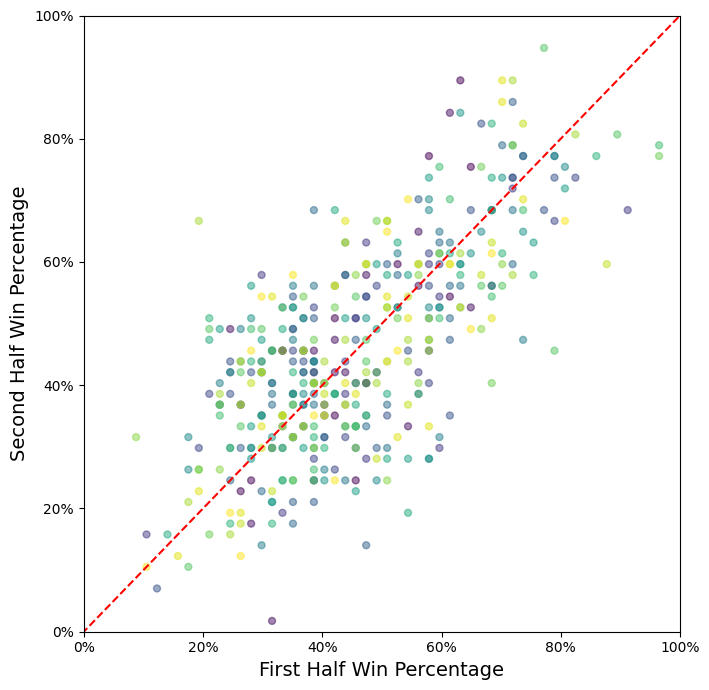

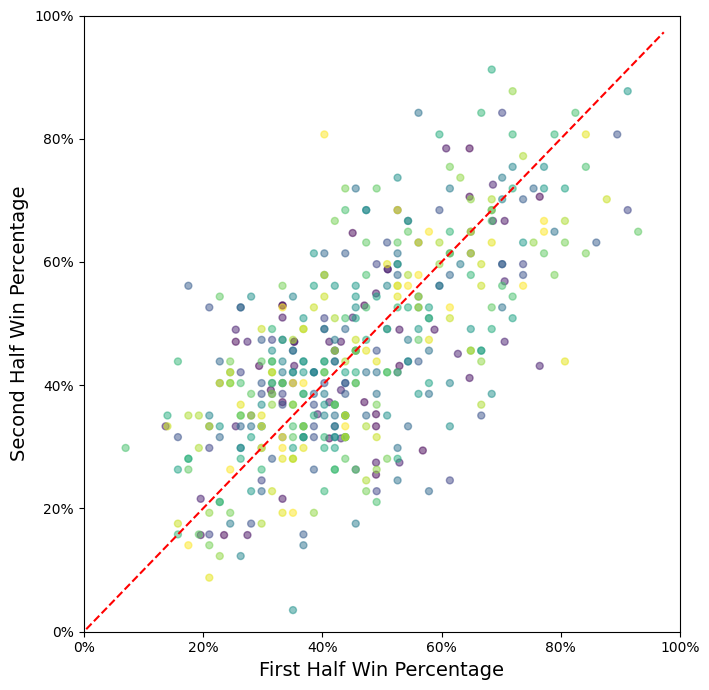

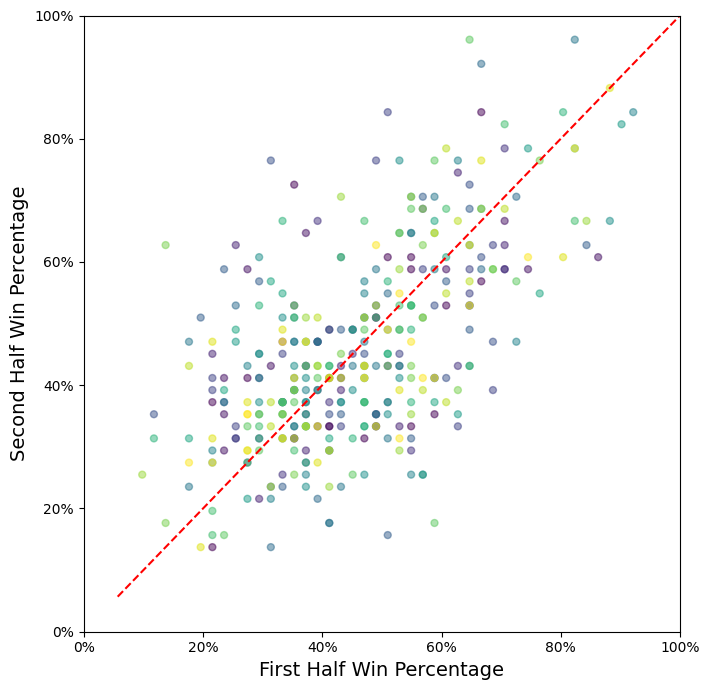

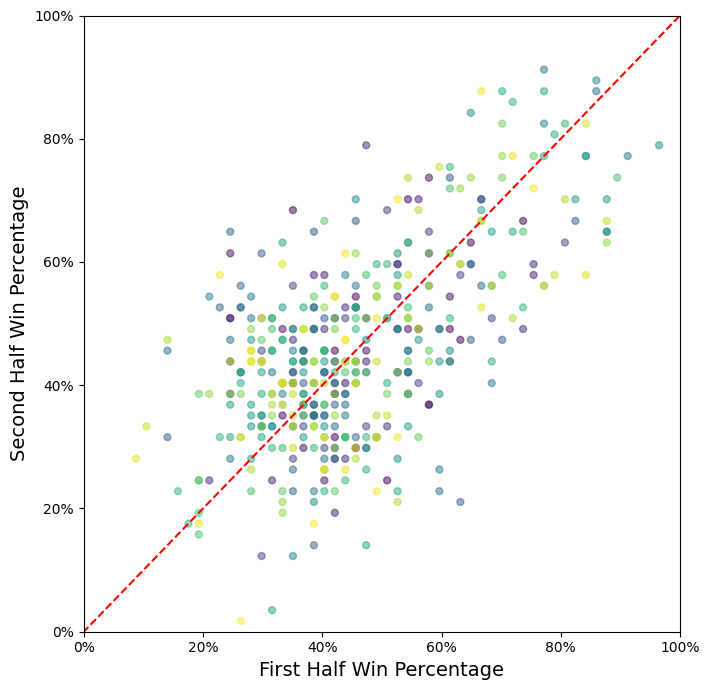

In [157]:
print(allleagues)
import matplotlib.ticker as mtick

for league in league_data:
    fig, ax = plt.subplots(figsize=(7,7), constrained_layout=True)
    df = allleagues[allleagues["league"] == league].copy()
    df["season"] = df["season"].astype(int)

     #/ by points per game and divide by 3 to get win percentage
    

    df.plot(
        x="first_half_goals", y="second_half_goals", kind="scatter", ax=ax, marker='o', alpha=0.5, s=25,          # circle marker
        c=df["season"],  # 'c' instead of 'color' for a color map
        cmap="viridis"
    )
    # Remove the automatic colorbar
    for cbar in ax.figure.axes:
        if cbar is not ax:  # any other axes besides main one
            cbar.remove()
    # ax.set_aspect('equal', adjustable='box')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

    min_val = min(plt.xlim()[0], plt.ylim()[0])
    max_val = max(plt.xlim()[1], plt.ylim()[1])
    line_vals = np.linspace(min_val, max_val, 100) # Generate points for the line
    plt.xlim(0, 100)
    plt.ylim(0, 100)

# Plot the y=x line
    plt.plot(line_vals, line_vals, color='red', linestyle='--', label='y=x')
    plt.title("")
    plt.xlabel("First Half Win Percentage", fontsize = 14)
    plt.ylabel("Second Half Win Percentage", fontsize = 14)
    plt.tight_layout()
    plt.savefig(f"{league}_correlation.png".lower())


